In [1]:
import sys
import os

# This is the backend folder
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
from ai_workspace.lecture_processor.v2.lecture_processing_v2 import (
    graph as lecture_processor,
)

## Annotating Pages

When working with large language models (LLMs) to extract content from lecture PDFs, one major challenge is token efficiency. Each page of a PDF is often converted to an image, and passing that image to the model for processing can consume a significant number of tokens—especially if most pages don’t contain relevant content. This leads to wasted computation and potentially lower-quality extractions, since irrelevant pages dilute the focus of the model.

To address this, I developed an experimental annotation feature that enhances the preprocessing stage of PDF analysis:

### Annotate each page image by adding:
- A circle marker.
- The page number.
- Run a lightweight initial analysis pass to identify the specific range of pages that likely contain questions or derivations.
- Optionally restrict extraction to only those key pages.

### 💡 Why This Helps
- A typical lecture might be 20 pages long, but only 3–5 pages contain actual questions or technical derivations.
- By narrowing down to just the important pages:
- We reduce token usage significantly.
- We improve extraction quality by focusing the model’s attention on relevant content.
- We retain full traceability thanks to the visual annotations, which make it easier to review and debug which pages were analyzed.

### ⚙️ Optional Parameter
This feature is optional and can be toggled via a parameter. It’s especially useful during experimentation or when processing large batches of lectures where optimization is critical.


In [2]:
from ai_workspace.utils.helper import pdf_to_image_persistent

# Define the path
pdf_path = (
    r"C:\Users\lberm\OneDrive\Documents\Github\gestalt_app\Lectures\Lec11-post.pdf"
)
output_dir = os.path.join(os.path.dirname(pdf_path), "lecture_images")
os.makedirs(output_dir, exist_ok=True)

### Without Annotation

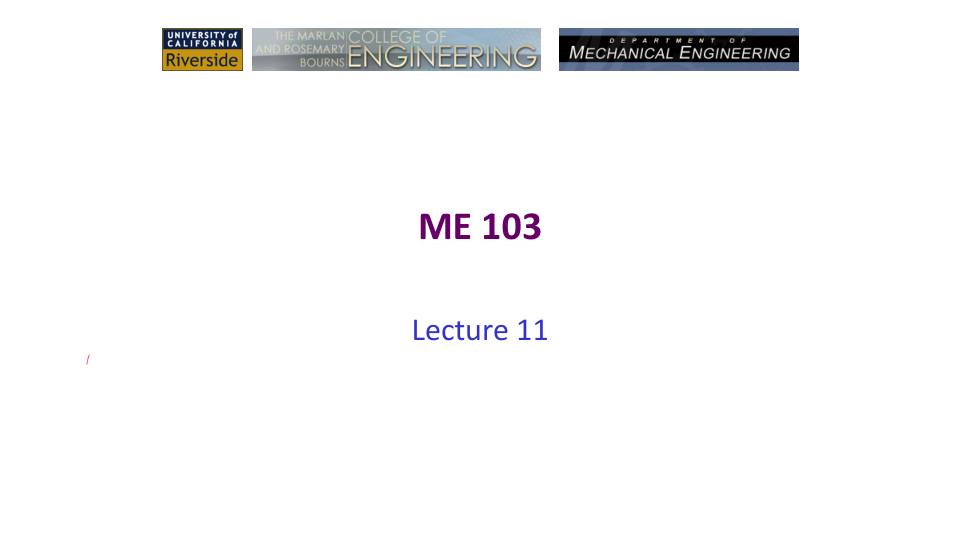

['C:\\Users\\lberm\\OneDrive\\Documents\\Github\\gestalt_app\\Lectures\\lecture_images\\Lec11-post\\Lec11-post_page_0.png', 'C:\\Users\\lberm\\OneDrive\\Documents\\Github\\gestalt_app\\Lectures\\lecture_images\\Lec11-post\\Lec11-post_page_1.png', 'C:\\Users\\lberm\\OneDrive\\Documents\\Github\\gestalt_app\\Lectures\\lecture_images\\Lec11-post\\Lec11-post_page_2.png', 'C:\\Users\\lberm\\OneDrive\\Documents\\Github\\gestalt_app\\Lectures\\lecture_images\\Lec11-post\\Lec11-post_page_3.png', 'C:\\Users\\lberm\\OneDrive\\Documents\\Github\\gestalt_app\\Lectures\\lecture_images\\Lec11-post\\Lec11-post_page_4.png', 'C:\\Users\\lberm\\OneDrive\\Documents\\Github\\gestalt_app\\Lectures\\lecture_images\\Lec11-post\\Lec11-post_page_5.png', 'C:\\Users\\lberm\\OneDrive\\Documents\\Github\\gestalt_app\\Lectures\\lecture_images\\Lec11-post\\Lec11-post_page_6.png', 'C:\\Users\\lberm\\OneDrive\\Documents\\Github\\gestalt_app\\Lectures\\lecture_images\\Lec11-post\\Lec11-post_page_7.png', 'C:\\Users\\lbe

In [30]:
# Create a persistent directory and get the image path
image_paths = await pdf_to_image_persistent(
    pdf_path=pdf_path, persistent_directory=output_dir, annotate=False
)
print(image_paths)

## Extracting Content Ranges

### Without Annotation

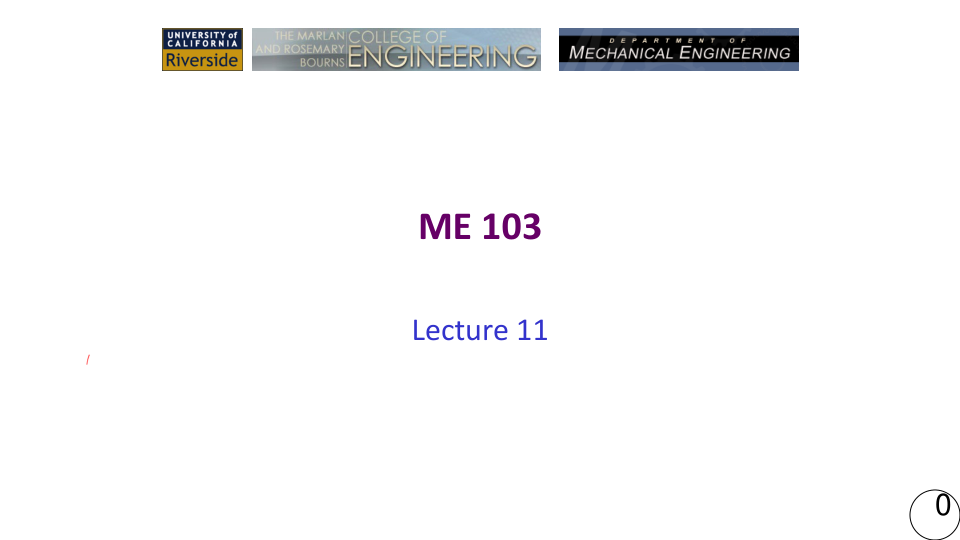

In [110]:
from ai_workspace.extraction.v1.extract_content_ranges import extract_question_ranges

image_paths = await pdf_to_image_persistent(
    pdf_path=pdf_path, persistent_directory=output_dir, annotate=True
)
page_ranges = await extract_question_ranges(image_paths)

### Displaying the Range


📄 Detected page ranges for the question:
[PageRange(range=[3, 6]), PageRange(range=[7, 8]), PageRange(range=[9, 12])]

🟦 Displaying images for Range 1 (3–6):


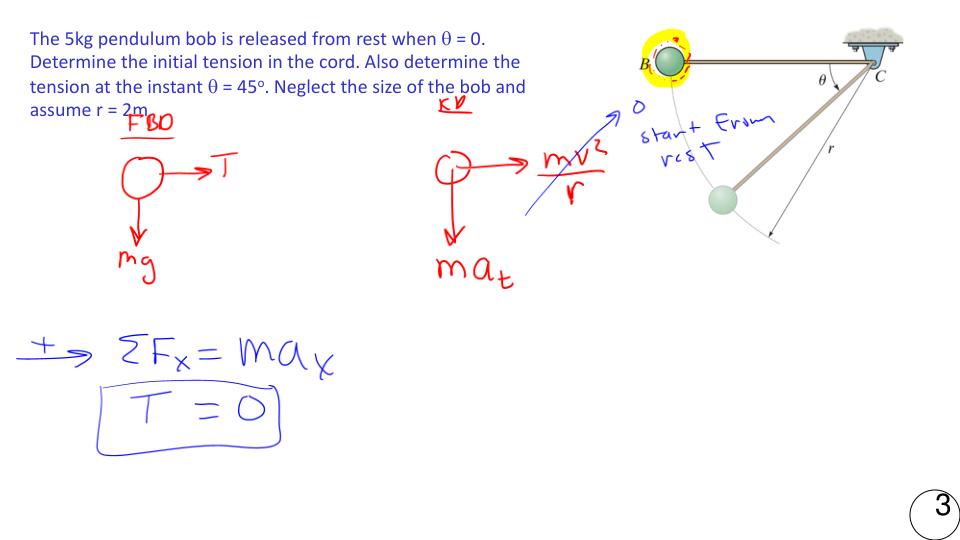

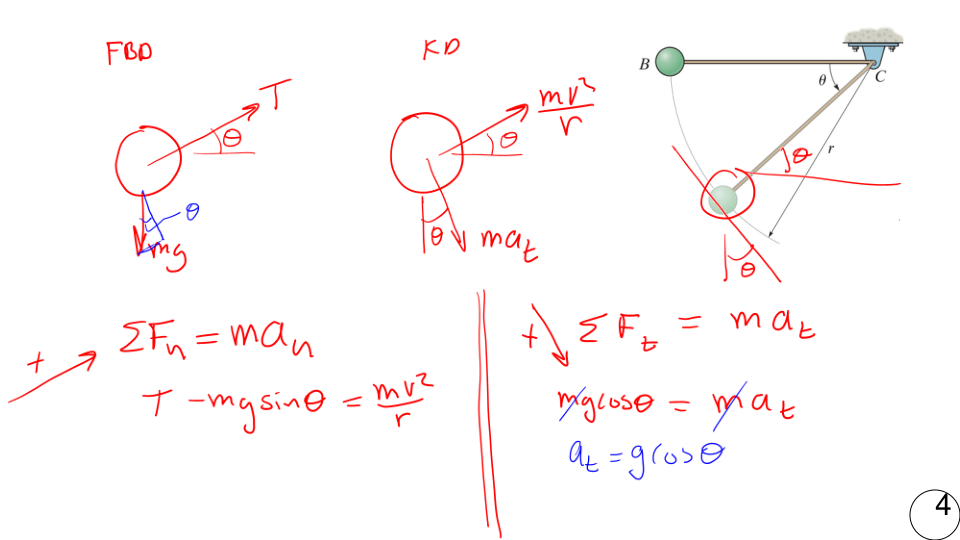

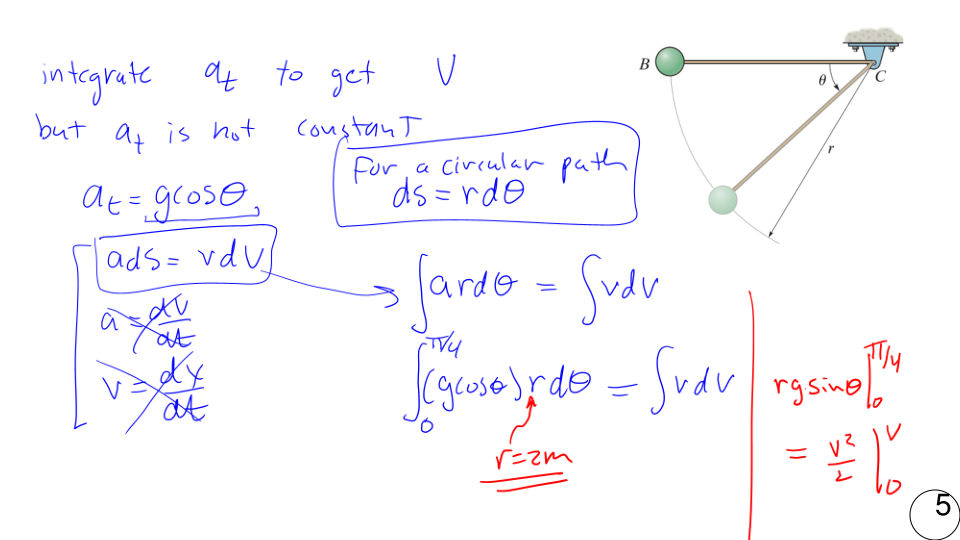

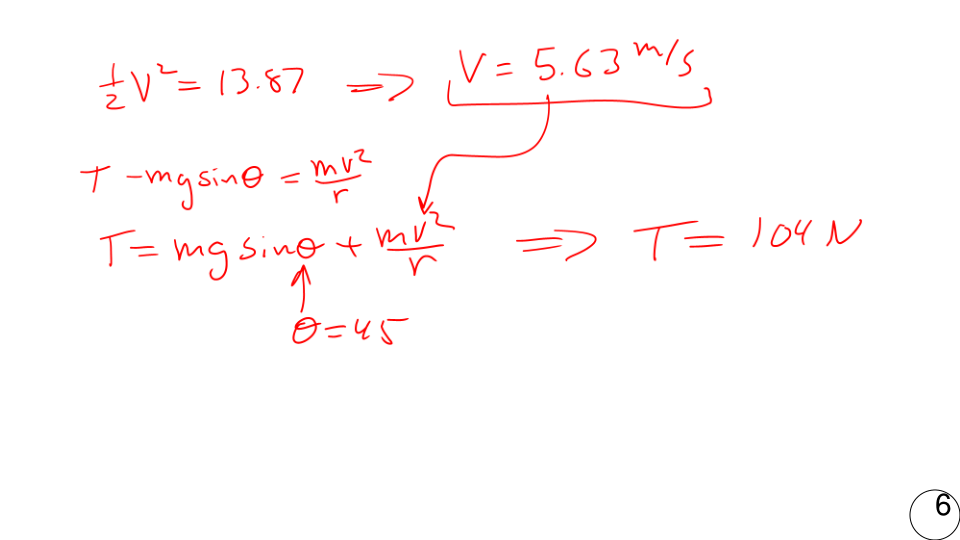


🟦 Displaying images for Range 2 (7–8):


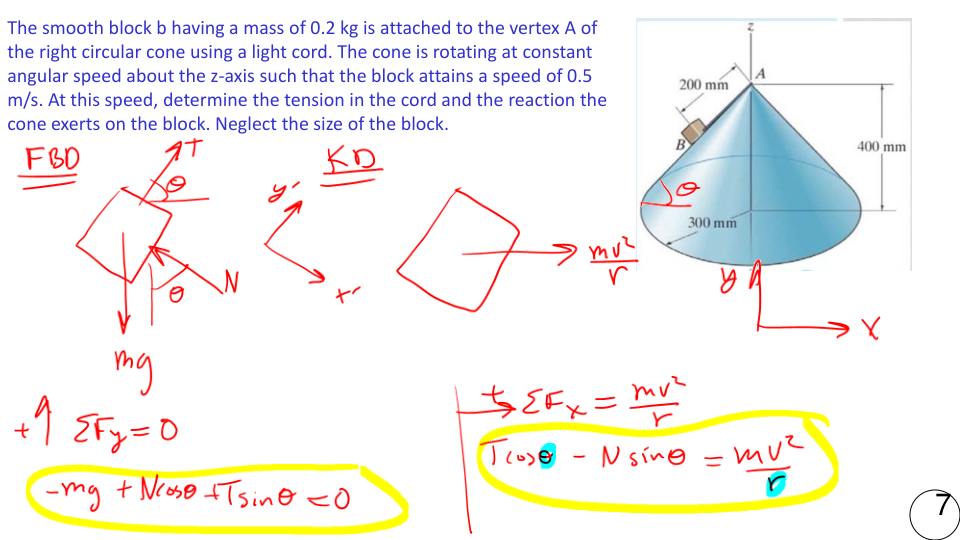

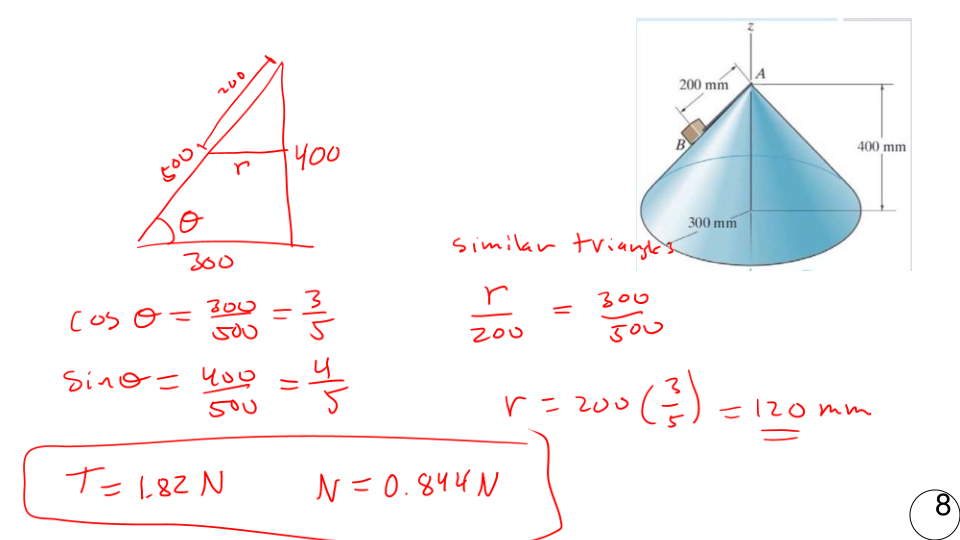


🟦 Displaying images for Range 3 (9–12):


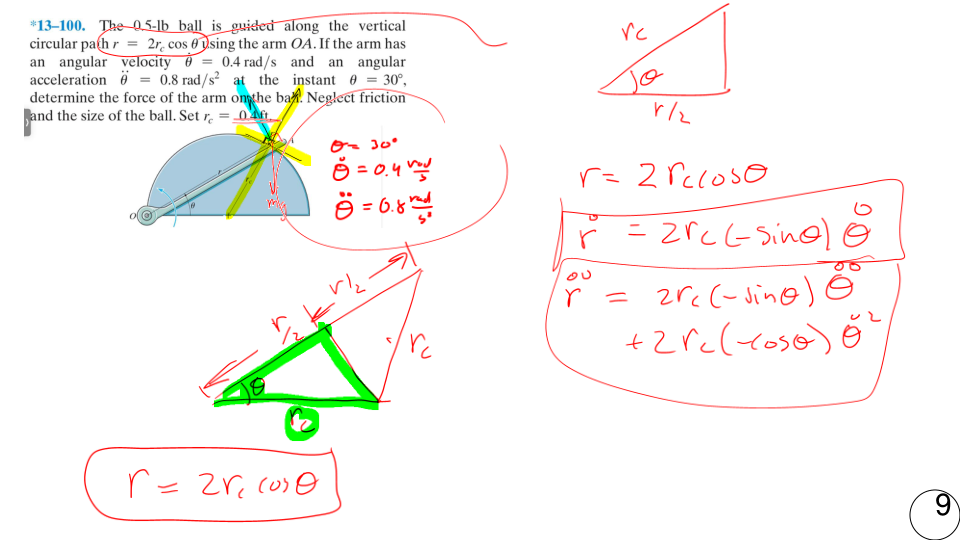

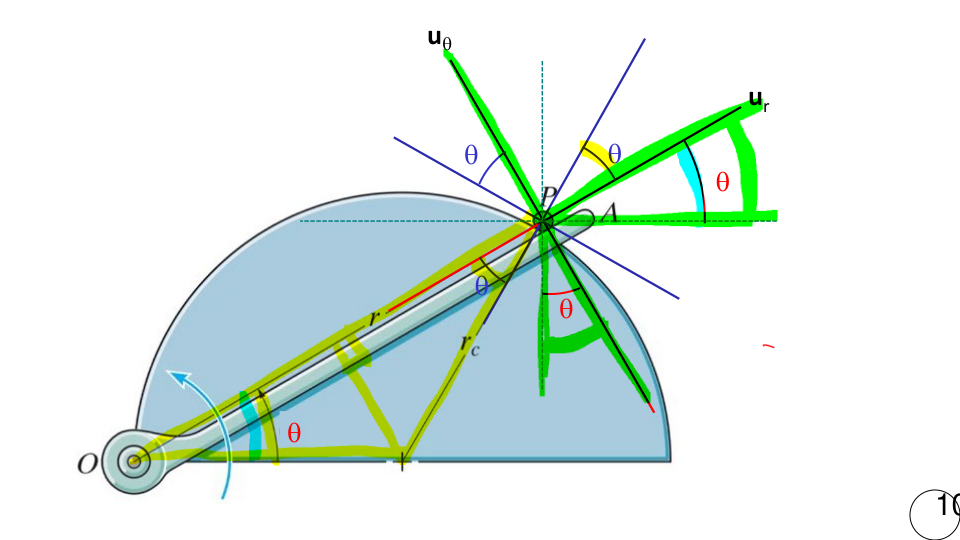

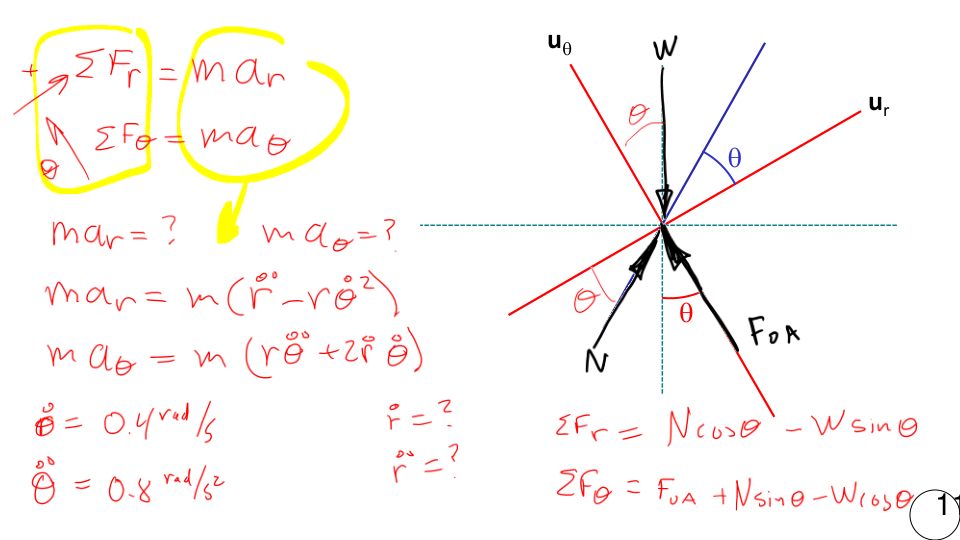

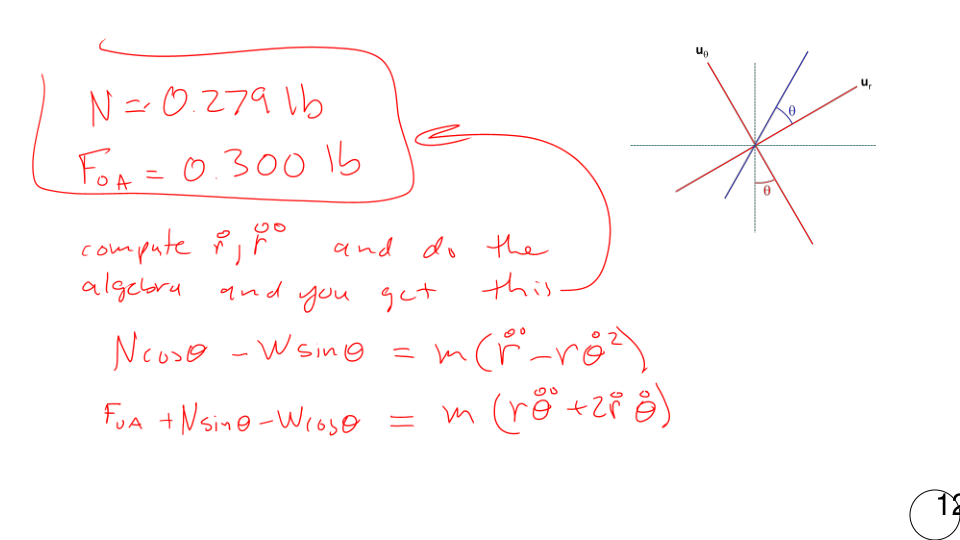

In [111]:
from IPython.display import display, Image

# Extract the first set of content ranges
instances = page_ranges["content_ranges"].ranges
print(f"\n📄 Detected page ranges for the question:\n{instances}\n")

# Loop through each page range and display associated images
for idx, prange in enumerate(instances, 1):
    start, end = prange.range
    selected_paths = image_paths[start : end + 1]

    print(f"🟦 Displaying images for Range {idx} ({start}–{end}):")
    for path in selected_paths:
        display(Image(filename=path))

    print(f"{'=' * 40}\n")


### Lecture Processing Graph Overview

This workflow begins with a `content_analysis` step that conditionally triggers derivation and question extraction based on the presence of relevant content. The `extract_lecture_summary` node is always executed to generate a general overview of the lecture.

- If **questions** are detected, `extract_lecture_questions` is run, followed by `generate_gestalt_modules`, which processes each question and its solution into a standalone educational module (via a separate subgraph).
- If **derivations** are detected, `extract_lecture_derivations` handles their extraction.
- All extracted content (summary, questions, and derivations) is merged in `finalize_lecture`, which compiles a wiki-style article.
- Finally, `finalize_package` standardizes the output into the desired structured format.


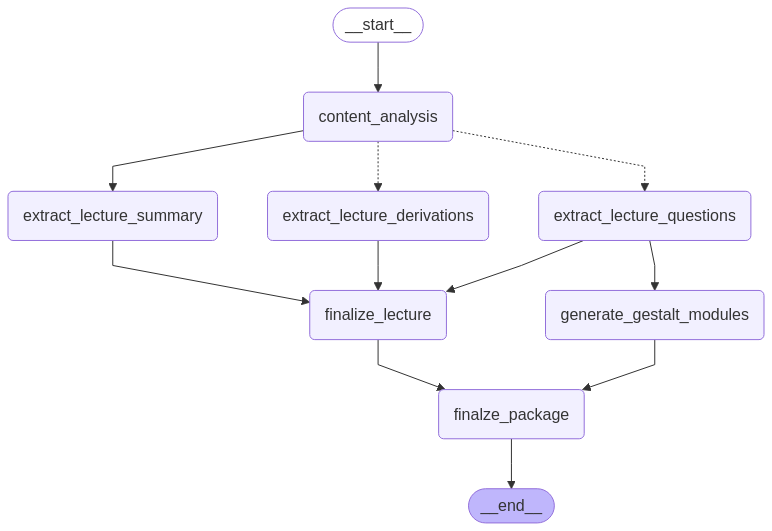

✅ Saved graph visualization at: c:\Users\lberm\OneDrive\Documents\Github\gestalt_app\backend\ai_workspace\notebooks\ProcessLectureChain.png


In [6]:
# Defining the input
from ai_workspace.lecture_processor.v2.lecture_processing_v2 import (
    LectureMetadata,
    LectureInputState,
    LectureOutputState,
    save_graph_visualization,
    to_serializable
)
import json

basepath = os.getcwd()
save_graph_visualization(
        lecture_processor,
        filename="ProcessLectureChain.png",
        base_path=basepath,
    )


### Running the Lecture Processing Graph

To run the graph, provide the following inputs:

- **Image paths** from the lecture PDF (a list of image paths this will be processed before hand)
- **Lecture metadata** (recommended), including title, course info, instructor name, date, and term
- **Image separation flag** to indicate whether pages should be processed individually

These inputs are passed to the backend endpoint, which then runs the graph asynchronously—streamlining integration with the frontend.


In [ ]:
pdf_path = (
    r"C:\Users\lberm\OneDrive\Documents\Github\gestalt_app\Lectures\Lec11-post.pdf"
)
image_paths = await pdf_to_image_persistent(
    pdf_path=pdf_path, persistent_directory=output_dir, annotate=True
)
metadata = LectureMetadata(
    lecture_title="Lecture 11",
    course_name="Dynamics",
    course_code=103,
    instructor_name="Thomas Stahovich",
    semester="Spring 2025",
)
graph_input = LectureInputState(
    image_paths=image_paths, seperate_image=True, lecture_metadata=metadata
)
result: LectureOutputState = await lecture_processor.ainvoke(graph_input)



### Saving Content to JsonFile
The content is essentially save in a json structure so we can later get information as needed 

### Lecture Output Format Overview

The output is structured into a comprehensive object called `LectureOutputState`, which captures the entire lecture processing result. It includes:

- **Lecture metadata**: Optional context like course name, instructor, and lecture date.
- **Image paths**: List of all images processed from the input lecture PDF.
- **Image separation flag**: Indicates if each page was processed individually.
- **Extracted content**: Parsed components from the lecture, including:
  - Summary
  - Derivations
  - Questions
- **Generated lecture**: A fully formatted lecture article, plus raw derivation and question strings for display.
- **Gestalt modules**: List of code-based modules created from the extracted questions.
- **Token usage**: Detailed tracking of token consumption throughout the pipeline.

This format ensures everything from raw inputs to final renderable content is captured in one structured response.


In [112]:
serializable = to_serializable(result)
with open(
    os.path.join(basepath, "processed_lecture.json"),
    "w",
) as f:
    json.dump(serializable, f, indent=4, default=str)

c:\Users\lberm\OneDrive\Documents\Github\gestalt_app\.venv\Lib\site-packages\pydantic\main.py:426: UserWarning: Pydantic serializer warnings:
  Expected `bool` but got `str` with value `'True'` - serialized value may not be as expected
  return self.__pydantic_serializer__.to_python(
c:\Users\lberm\OneDrive\Documents\Github\gestalt_app\.venv\Lib\site-packages\pydantic\main.py:426: UserWarning: Pydantic serializer warnings:
  Expected `bool` but got `str` with value `'False'` - serialized value may not be as expected
  return self.__pydantic_serializer__.to_python(


### Lecture 

In [113]:
from IPython.display import display, HTML, Markdown, Image, Latex
display(Markdown(result["generated_lecture"].final_lecture))

# Kinetics of Particles and Rigid Body Equations of Motion

## Metadata
- **Course**: Dynamics-103  
- **Instructor**: Thomas Stahovich  
- **Term**: Spring 2025

*This lecture is part of the core sequence in undergraduate Engineering Dynamics, focusing on applying Newtonian principles to both particle and rigid body motion. It transitions students from static equilibrium to dynamic force and moment analysis.*

---

## Table of Contents
1. [Introduction](#introduction)
2. [Core Concepts](#core-concepts)
    1. [Newton's Second Law for Particles](#newtons-second-law-for-particles)
    2. [Free-Body Diagrams and Kinetic Diagrams](#free-body-diagrams-and-kinetic-diagrams)
    3. [Equations of Motion for Rigid Bodies](#equations-of-motion-for-rigid-bodies)
    4. [Moment of Inertia and the Parallel Axis Theorem](#moment-of-inertia-and-the-parallel-axis-theorem)
    5. [Tangential and Normal Directions in Polar Coordinates](#tangential-and-normal-directions-in-polar-coordinates)
3. [Mathematical Derivations](#mathematical-derivations)
    1. [Moment Equation for a Rigid Body](#moment-equation-for-a-rigid-body)
    2. [Equations of Motion in Plane Polar Coordinates](#equations-of-motion-in-plane-polar-coordinates)
4. [Example Problems & Solutions](#example-problems--solutions)
    1. [Pendulum Tension Calculation](#pendulum-tension-calculation)
    2. [Conical Rotation: Tension and Normal Force](#conical-rotation-tension-and-normal-force)
    3. [Particle on a Variable Circular Path](#particle-on-a-variable-circular-path)
5. [Conclusion](#conclusion)

---

## Introduction

The study of kinetics in engineering dynamics involves understanding how forces and torques (moments) act on particles and rigid bodies in motion. This lecture builds on Newton’s Second Law to develop the equations governing the motion of both point particles and extended bodies, introduces fundamental analytical tools such as the free-body diagram, and solves complex symbolic problems relevant to engineering mechanisms.

Understanding these principles is essential for analyzing the behavior of machines, vehicles, robotic systems, and structures subjected to dynamic loading.

---

## Core Concepts

### Newton's Second Law for Particles
Newton’s Second Law forms the foundation of classical dynamics. For a particle of mass $m$ subjected to a net force $\vec{F}$:

$$
\vec{F} = m \vec{a}
$$

where $\vec{a}$ is the acceleration. For scalar problems:
- $F = m a$ along the chosen coordinate direction.

This law enables the translation of force diagrams into equations of motion.

### Free-Body Diagrams and Kinetic Diagrams

A **free-body diagram (FBD)** is a graphical representation isolating a particle or body and illustrating all external forces acting on it. **Kinetic diagrams** supplement the FBD by indicating corresponding accelerations or inertias.

Drawing correct FBDs is integral for setting up Newton’s equations. For particles, forces typically include:
- Weight ($mg$)
- Normal force
- Tension
- Reaction forces

### Equations of Motion for Rigid Bodies
For planar motion of rigid bodies, Newton’s laws generalize to consider both translational and rotational effects:
- Translational:
  $$\sum \vec{F} = m\vec{a}_G$$
- Rotational about the center of mass $G$:
  $$\sum M_G = I_G \alpha$$
  where $I_G$ is the moment of inertia about $G$, and $\alpha$ is the angular acceleration.

### Moment of Inertia and the Parallel Axis Theorem
The moment of inertia, $I_P$, quantifies a body’s resistance to angular acceleration:

$$
I_P = \int_m r^2 dm
$$

When evaluating $I_P$ about a parallel axis (distance $d$ from the center of mass $G$):

$$
I_P = I_G + m d^2
$$

This is the **parallel axis theorem**.

### Tangential and Normal Directions in Polar Coordinates

Analyzing particle motion in polar coordinates provides:
- Tangential direction (along path): $a_t$
- Normal direction (toward the center of curvature): $a_n$

For a path defined by $r(\theta)$:
- $\tan \psi = \frac{r}{dr/d\theta}$, with arc length $ds = r d\theta$
- Normal and tangential acceleration components are derived accordingly.

---

## Mathematical Derivations

### Moment Equation for a Rigid Body

**Purpose:** To derive the equation describing rotational motion for a rigid body in a plane due to applied moments.

**Equation:**
$$
\sum M_G = I_G \alpha
$$
Here:
- $\sum M_G$ is the sum of moments about the center of mass $G$
- $I_G$ is the mass moment of inertia about $G$
- $\alpha$ is the angular acceleration

**Intuition:** The net external moment produces angular acceleration analogous to how force produces linear acceleration.

### Equations of Motion in Plane Polar Coordinates

**Purpose:** To develop force-balance equations for particles moving in a plane, particularly in radial and transverse (angular) directions.

#### 1. Derivatives of $r$ with respect to time
Given $r = r(\theta)$ (e.g., $r = 2r_c \cos \theta$):

- First derivative:
  $$
  \dot{r} = \frac{dr}{dt} = \frac{dr}{d\theta} \dot{\theta}
  $$
- Second derivative (chain rule):
  $$
  \ddot{r} = \frac{d}{dt}(\dot{r}) = \frac{d^2r}{d\theta^2}(\dot{\theta})^2 + \frac{dr}{d\theta} \ddot{\theta}
  $$

#### 2. General Equations of Motion
- **Radial direction:**
  $$
  \sum F_r = m a_r = m(\ddot{r} - r \dot{\theta}^2)
  $$
- **Transverse (\(\theta\)) direction:**
  $$
  \sum F_{\theta} = m a_{\theta} = m(r \ddot{\theta} + 2 \dot{r} \dot{\theta})
  $$

#### 3. Force Equilibrium with Reaction Forces
For a particle subject to normal force $N$, weight $W=mg$, and a force from an arm $F_{OA}$:
- **Radial:**
  $$
  N \cos\theta - W \sin\theta = m(\ddot{r} - r \dot{\theta}^2)
  $$
- **Transverse:**
  $$
  F_{OA} + N \sin\theta - W \cos\theta = m(r \ddot{\theta} + 2 \dot{r} \dot{\theta})
  $$

**Note:** These balances allow for symbolic solution of unknown reaction forces given the kinematic relations.

---

## Example Problems & Solutions

### 1. Pendulum Tension Calculation
> **Question:**  
> The 5 kg pendulum bob is released from rest when $\theta = 0$. Determine the initial tension in the cord and the tension at $\theta = 45^\circ$. (Given: $r=2\ \text{m}$. Neglect bob size.)

#### **Solution:**
- **At $\theta = 0$:**
  Only gravity and tension act; no motion yet (rest ⇒ $a=0$):
  $$
  \sum F_r = T - mg = 0 \implies T = mg
  $$
  \*Initial tension is $T_0 = mg$.*

- **At $\theta = 45^\circ$:**
  Forces:
  $$
  T - mg\sin \theta = \frac{mv^2}{r}
  $$
  $v$ found using energy or integrating tangential acceleration:
  $$
  g r \int_0^{\pi/4} \cos \theta d\theta = \int_0^{v_{45}} v dv
  $$
  $$
  gr (\sin(45^\circ) - \sin(0)) = \frac{1}{2} v_{45}^2
  $$
  Substitute $v_{45}$ into tension equation:
  $$
  T_{45} = mg\sin(45^\circ) + \frac{m v_{45}^2}{r}
  $$

*This problem reinforces the connection between force analysis and kinematics for curved motion.*

### 2. Conical Rotation: Tension and Normal Force
> **Question:**
> A mass $m$ rotates with speed $v$ at the surface of a smooth right circular cone (see figure). Find, symbolically:  
> (a) the tension $T$ in the string;  
> (b) the reaction $N$ from the cone.  
> Express using $m$, $g$, $v$, $r$, cone geometry ($\theta$).

#### **Solution:**
- Draw Free Body Diagram: forces are gravity ($mg$ downward), tension ($T$ in chord), and normal ($N$ from cone), each at known angles.
- Write equilibrium along vertical $(y')$ and horizontal/radial $(x')$ axes:
  - Vertical:
    $$
    -N \cos \theta - T \sin \theta + mg = 0
    $$
  - Radial:
    $$
    T \cos \theta - N \sin \theta = m \frac{v^2}{r}
    $$
- Solve simultaneously:
    
  $N \cos \theta + T \sin \theta = mg$
  
  $T \cos \theta - N \sin \theta = m \frac{v^2}{r}$

- Symbolic solution by algebraic manipulation yields $T$ and $N$ in terms of $m, g, v, r, \theta$.
- Geometry provides $r$ via:
   $$
   r = L \cos \theta
   $$
   or similar relations depending on cone proportions.

*This problem illustrates the application of force balances in non-inertial (rotating) systems and the use of geometry in kinetic problems.*

### 3. Particle on a Variable Circular Path
> **Question:**
> A $0.5$-lb ball is guided along $r = 2r_c \cos \theta$ by arm $OA$. At $\theta = 30^\circ$: $\dot{\theta}=0.4$ rad/s, $\ddot{\theta}=0.8$ rad/s$^2$. Find the force arm $OA$ exerts on the ball (symbolically, in terms of $m$, $r_c$, $\theta$, $\dot{\theta}$, $\ddot{\theta}$).

#### **Solution:**
- **Step 1: Kinematics**
  - $r = 2r_c \cos\theta$
  - $\dot{r} = -2r_c \sin\theta\ \dot{\theta}$
  - $\ddot{r} = -2r_c [\cos\theta\ (\dot{\theta})^2 + \sin\theta\ \ddot{\theta}]$

- **Step 2: Equations of Motion in Polar Coordinates**
  - Radial:
    $$
    N \cos\theta - mg \sin\theta = m (\ddot{r} - r \dot{\theta}^2)
    $$
  - Transverse:
    $$
    F_{OA} + N \sin\theta - mg \cos\theta = m (r \ddot{\theta} + 2 \dot{r} \dot{\theta})
    $$
  - Solve for $N$ and $F_{OA}$ as functions of $m, r_c, \theta, \dot{\theta}, \ddot{\theta}$.

*This example shows the power of variable substitution and application of polar coordinate dynamics to mechanism analysis.*

---

## Conclusion

Kinetics bridges the gap between force and motion for both particles and rigid bodies. Through Newton’s laws, free-body diagrams, and appropriate coordinate systems (Cartesian or polar), one can systematically analyze and symbolically solve for unknowns in a wide variety of mechanical systems. Key takeaways include:
- Importance of constructing accurate force and kinetic diagrams
- Rigorous application of Newton’s Second Law in both translation and rotation
- Critical role of geometry and kinematics in multi-variable motion problems

**Extensions:** Advanced study may include energy methods (work-energy, power), three-dimensional motion, or non-inertial reference frames (moving coordinates, Coriolis effects).


### Lecture Base

The lecture base is just the basic summary that was extracted before clean up. It is saved so if we want to reference it. 

In [114]:
display(Markdown(result["generated_lecture"].lecture_base))

# Kinetics of Particles and Rigid Body Equations of Motion
 This lecture introduces the kinetics of particles using Newton’s Second Law, explores free body and kinetic diagrams, and develops the equations of motion for both particles and rigid bodies. It covers the derivation and significance of force and moment equations, including constraints for planar motion, and provides worked example problems involving tension and reactions in mechanical systems.  

## Understanding of Particle Kinetics

Students should be able to apply Newton’s Second Law to particles, draw correct free-body diagrams, and relate forces to particle motion.

## Analyzing Mechanical Systems Symbolically

Students will solve mechanical equilibrium and motion problems strictly symbolically, identifying key variables and parameters.

## Rigid Body Kinetics Derivation

Students should understand the derivation of generalized force and moment equations for rigid body motion and know their applicability.

## Understanding of Particle Kinetics

Students should be able to apply Newton’s Second Law to particles, draw correct free-body diagrams, and relate forces to particle motion.

## Analyzing Mechanical Systems Symbolically

Students will solve mechanical equilibrium and motion problems strictly symbolically, identifying key variables and parameters.

## Rigid Body Kinetics Derivation

Students should understand the derivation of generalized force and moment equations for rigid body motion and know their applicability.

## Newton’s Second Law for Particles

Describes the relationship: \( \vec{F} = m \vec{a} \), where \( \vec{F} \) is the net force, \( m \) the mass, and \( \vec{a} \) the acceleration.

## Equations of Motion for Rigid Bodies

The translational and rotational equations:
\( \Sigma \vec{F} = m\vec{a}_G \)
\( \Sigma M_G = I_G \alpha \ ).

## Moment of Inertia

Defined as \( I_P = \int_m r^2 dm \). Parallel axis theorem: \( I_P = I_G + md^2 \).

## Tangential and Normal Directions in Polar Coordinates

\( \tan \psi = \frac{r}{dr/d\theta} \), \( ds = r d\theta \); normal and tangential acceleration components.

### Lecture Questions
The lecture questions are also saved and used for when we finalize the questions. Additionally this is the solution guide that is being used for the gestalt modules

In [36]:
display(Markdown(result["generated_lecture"].question_str))

The 5\,\mathrm{kg} pendulum bob is released from rest when \( \theta = 0 \).\newline Determine the initial tension in the cord. Also determine the tension at the instant \( \theta = 45^\circ \).\newline Neglect the size of the bob and assume \( r = 2\,\mathrm{m} \).

Source: Image 1 (slide 3)

## Understanding the Problem

A pendulum bob of mass \( m = 5\,\mathrm{kg} \) is attached to a cord of length \( r = 2\,\mathrm{m} \), released from rest with \( \theta = 0 \). We are to determine: (1) the initial tension in the cord when \( \theta = 0 \); (2) the tension when \( \theta = 45^\circ \).

## Free-Body Diagram and Force Analysis at \( \theta = 0 \)

At \( \theta = 0 \), the bob is at rest and only two forces act on it: gravity (\( mg \)) and the tension \( T \) in the cord. Since the bob is at rest, the net force in the radial direction is zero.

### Force equation at \( \theta = 0 \)

\( \sum F_r = m a_r \rightarrow T - mg = 0 \implies T = mg \)\newline Thus, the initial tension is \( T = mg \).

## Free-Body Diagram and Force Analysis at General \( \theta \)

At an arbitrary angle \( \theta \), the forces are gravity (decomposed into radial and tangential components) and tension. The radial equation is:

### Radial force equation

\( \sum F_n = m a_n \implies T - mg\sin\theta = \frac{mv^2}{r} \implies T = mg\sin\theta + \frac{mv^2}{r} \)

## Finding the Speed \( v \) at \( \theta = 45^\circ \) Symbolically

Use the tangential acceleration to find the velocity at \( \theta = 45^\circ \).\newline Tangential component: \( m g \cos\theta = m a_t \implies a_t = g\cos\theta \).\newline Use energy or kinematics for a variable tangential acceleration.

### Differential for variable \( a_t \) in a circular arc

Since \( a_t = g\cos\theta \),\newline \( a_t = \frac{dv}{dt} = g\cos\theta \)\newline For a circular path, \( ds = r d\theta \).\newline \( a_t = \frac{dv}{dt} = \frac{dv}{ds}\frac{ds}{dt} = v \frac{dv}{ds} \).\newline So, \( a_t ds = v dv \implies g\cos\theta \cdot r d\theta = v dv \)

## Integration to Find \( v \) at \( \theta = 45^\circ \)

Integrate both sides from \( \theta = 0 \) and \( v=0 \), to \( \theta = 45^\circ \) and \( v = v_{45} \):\newline \[ \int_0^{\pi/4} g r \cos\theta d\theta = \int_0^{v_{45}} v dv \]

### Result of integration (symbolic)

\[ g r \int_0^{\pi/4} \cos\theta d\theta = \frac{1}{2} v_{45}^2 \]

## Expression for the Tension at \( \theta = 45^\circ \)

Substitute the symbolic result for \( v_{45} \) into the tension equation: \newline \[ T_{45} = mg\sin(45^\circ) + \frac{m v_{45}^2}{r} \]

At a constant angular speed about the z-axis, a smooth block B of mass m is attached to the vertex A of a right circular cone using a light cord. The block attains a speed v. At this speed, determine symbolically:
(a) the tension T in the cord, and
(b) the reaction N that the cone exerts on the block.
Neglect the size of the block. The relevant parameters are the cone's dimensions and the geometry as shown in the diagram.

Source: Slide 7 (first image, problem statement)

## Free Body Diagram and Force Equilibrium

Draw a free body diagram (FBD) for the block, identifying:
- Gravity acting downward: mg
- Tension T in the cord at angle \( \theta \)
- Reaction force (normal), N, from the cone at angle \( \theta \)

Consider components of forces along the vertical (y') and horizontal (x', towards the axis of rotation) directions.

### Vertical Equilibrium (\( \Sigma F_{y'} = 0 \))

\[
-N \cos \theta - T \sin \theta + mg = 0
\]

### Radial/Centripetal Equilibrium (\( \Sigma F_{x'} = m\frac{v^2}{r} \))

\[
T \cos \theta - N \sin \theta = m \frac{v^2}{r}
\]

## Geometric Relations from the Cone

Let the slant height (hypotenuse) from apex A to B be L, the vertical height be h, and the base radius be b. From the diagram, assign symbolic lengths as needed.
- \( \cos \theta = \frac{b}{L} \)
- \( \sin \theta = \frac{h}{L} \)
- Let the radius of motion (horizontal distance from axis to block), r, be found by similar triangles or direct trigonometric relations.

## Solve Simultaneous Equations

Solve the two equations from the FBD:
\[
-N \cos \theta - T \sin \theta + mg = 0 \tag{1}
\]
\[
T \cos \theta - N \sin \theta = m \frac{v^2}{r} \tag{2}
\]
Symbolically solve for T and N in terms of m, g, v, r, and \( \theta \):

### Solution for Tension (T) and Normal Reaction (N)

Solve (1) and (2) for T and N:
\begin{align*}
N \cos \theta + T \sin \theta &= mg \\
T \cos \theta - N \sin \theta &= m \frac{v^2}{r}
\end{align*}
Solve these simultaneously to express T and N symbolically.

What is the significance of the radius r in determining the required tension and normal force, and how is it extracted from the geometry of the cone?

Source: Slide 8 (second image, geometric construction)

## Geometric Analysis of the Cone

Construct a right triangle from the apex, slant height, and base radius, noting:
- Slant height = L
- Height = h
- Base radius = b

From similar triangles or trigonometry:
\[
\cos \theta = \frac{b}{L}
\]
\[
\sin \theta = \frac{h}{L}
\]
Let the required radius of rotation be r.

### Similar Triangles or Trigonometric Relationship for r

If cord length from apex to block (slant height) is known (L), and projection to axis is proportionate to the base:
\[
r = L \cos \theta
\]
Or from similar triangles:
\[
\frac{r}{L} = \frac{b}{\text{slant height (total)}}
\]
The specific symbolic relation should reflect the geometry as depicted.

The 0.5-lb ball is guided along the vertical circular path $r = 2r_c \cos\theta$ using the arm $OA$. If the arm has an angular velocity $\dot{\theta} = 0.4\ \text{rad}/s$ and an angular acceleration $\ddot{\theta} = 0.8\ \text{rad}/s^2$ at the instant $\theta = 30^\circ$, determine the force of the arm on the ball. Neglect friction and the size of the ball. Set $r_c = 0.4\ \text{m}$.

Source: Image 1 (textbook and annotations, problem 13-100)

## General Symbolic Solution Steps

We will write a symbolic solution, using only variables: $m$, $\theta$, $r_c$, $g$, etc. Numerical values will not be substituted.

### 1. Express Ball's Radial Position as a Function of $\theta$

$r = 2r_c \cos \theta$

First derivatives:
$$
\dot{r} = \frac{dr}{dt} = \frac{dr}{d\theta}\dot{\theta} = 2r_c (-\sin\theta)\dot{\theta}
$$
Second derivatives:
$$
\ddot{r} = \frac{d^2r}{dt^2} = 2r_c\left(-\cos\theta\ (\dot{\theta})^2 - \sin\theta\ \ddot{\theta}\right)
$$

### 2. Write Out Radial and Transverse ($\theta$) Equations of Motion

Radial direction ($r$):
$$
\sum F_r = m a_r
$$
where 
$$a_r = \ddot{r} - r (\dot{\theta})^2
$$

Transverse direction ($\theta$):
$$
\sum F_{\theta} = m a_{\theta}
$$
where
$$
a_{\theta} = r \ddot{\theta} + 2 \dot{r} \dot{\theta}
$$

### 3. Free-Body Diagram Forces and Equations

Radial direction:
$$
\sum F_r = N \cos\theta - W \sin\theta
$$
Transverse (theta) direction:
$$
\sum F_{\theta} = F_{OA} + N \sin\theta - W \cos\theta
$$
where $N$ is the normal reaction and $F_{OA}$ is the force from the arm along the $\theta$ direction.

### 4. Final Symbolic Equations for Solving $N$ and $F_{OA}$

Radial equilibrium:
$$
N \cos\theta - m g \sin\theta = m(\ddot{r} - r (\dot{\theta})^2)
$$
Transverse equilibrium:
$$
F_{OA} + N \sin\theta - m g \cos\theta = m(r \ddot{\theta} + 2 \dot{r} \dot{\theta})
$$

You would solve these equations, symbolically, for $N$ and $F_{OA}$ in terms of $m, r_c, \theta, g, \dot{\theta}, \ddot{\theta}$. No numbers are substituted.

Given $r = 2r_c \cos\theta$, derive the first and second time derivatives $\dot{r}$ and $\ddot{r}$ in terms of $r_c$, $\theta$, $\dot{\theta}$, and $\ddot{\theta}$, using the chain rule.

Source: Image 1 (boxed red equations); also required in Image 3 for equation of motion setup

## Derivatives of $r$ with respect to time



### First Derivative $\dot{r}$

$$
r = 2r_c \cos \theta
$$
$$
\frac{dr}{dt} = \frac{dr}{d\theta} \frac{d\theta}{dt} = -2r_c \sin\theta\ \dot{\theta}
$$

### Second Derivative $\ddot{r}$

$$
\ddot{r} = \frac{d}{dt}(\dot{r}) = \frac{d}{dt}(-2r_c \sin\theta\ \dot{\theta})
$$
Using product rule:
$$
\ddot{r} = -2r_c (\cos\theta\ \dot{\theta}) \dot{\theta} - 2r_c \sin\theta \ddot{\theta}
$$
So
$$
\ddot{r}= -2r_c \cos\theta\ (\dot{\theta})^2 - 2r_c \sin\theta\ \ddot{\theta}
$$

Write the general equations of motion for the $r$ and $\theta$ directions for a particle moving in plane polar coordinates, expressing the acceleration components symbolically.

Source: Image 3 (yellow highlighted box and equations)

## Equations of Motion in Plane Polar Coordinates



### Radial Direction

$$
\sum F_r = m a_r
$$
where 
$$a_r = \ddot{r} - r (\dot{\theta})^2
$$

### Transverse $(\theta)$ Direction

$$\sum F_{\theta} = m a_{\theta}$$
where
$$
a_{\theta} = r \ddot{\theta} + 2 \dot{r} \dot{\theta}
$$

Write the symbolic equilibrium equations (force balances) in both $r$ and $\theta$ directions, showing how to include $N$, $W$, and $F_{OA}$, for the described problem.

Source: Image 3 and 4 (red equations lower right)

## Force Equilibrium Equations in $r$ and $\theta$ Directions



### Radial (r) Direction

$$
N \cos\theta - W \sin\theta = m (\ddot{r} - r \dot{\theta}^2)
$$

### Transverse $(\theta)$ Direction

$$
F_{OA} + N \sin\theta - W \cos\theta = m (r \ddot{\theta} + 2 \dot{r} \dot{\theta})
$$

### Accessing More
Each question's solution is returned as a formatted string, but additional structured data is available through the full JSON output.

This JSON follows a Pydantic model that includes detailed metadata from the question extraction process. Since this serves as the input for generating Gestalt modules, we can extend its use further.

For example:
- **Include external data** like water tables or material property files if required by the question.
- **Add validation** to detect and skip incomplete or improperly formatted questions.
- **Customize processing** based on metadata fields to enable smarter, more adaptive module generation.

This flexible structure enables beter control and adding features as needed.

In [ ]:
from pydantic import BaseModel,Field
from typing import Optional, Union,List
class Question(BaseModel):
    question: str = Field(
        ...,
        title="Question",
        description="A fully formed question. It should be complete and clearly stated.",
    )
    source: Optional[Union[str, int]] = Field(
        None,
        title="Source",
        description="The source from which the question was extracted. Ideally, this is a page number or identifier from lecture content or a textbook.",
    )
    requires_external_data: Optional[bool] = Field(
        None,
        title="Requires External Data",
        description="Whether the question depends on external data such as tables, charts, or datasets to be solved.",
    )
    requires_image: Optional[bool] = Field(
        None,
        title="Requires Image",
        description="Whether an image is required to fully understand the question.",
    )
    completeness: Optional[bool] = Field(
        None,
        title="Completeness",
        description="Whether the question or derivation is complete or requires additional steps.",
    )
    additiona_information: Optional[str] = Field(
        None,
        title="Additional instructions for code generation",
        description="Additional instructiosn for code generation",
    )
    solution: Optional[List[Section]] = Field(
        default_factory=list,
        title="Titles and descriptions for each solution step",
        description="The solution guide of the question any math should be delimited by $$ for block level and $ for inline ",
    )

    @property
    def as_str(self) -> str:
        solution_steps = (
            "\n\n".join(solution.as_str for solution in self.solution)
            if self.solution
            else None
        )
        source = f"\nSource: {self.source}" if self.source else ""
        return f"{self.question}\n{source}\n\n{solution_steps}".strip()

    @property
    def solution_as_str(self) -> str:
        return (
            "\n\n".join(solution.as_str for solution in self.solution)
            if self.solution
            else None
        )


In [115]:
formatted_json = result["extracted_content"].lecture_questions.model_dump_json(indent=2)
print(formatted_json)


{
  "questions": [
    {
      "question": "The 5\\,\\mathrm{kg} pendulum bob is released from rest when \\( \\theta = 0 \\).\\newline Determine the initial tension in the cord. Also determine the tension at the instant \\( \\theta = 45^\\circ \\).\\newline Neglect the size of the bob and assume \\( r = 2\\,\\mathrm{m} \\).",
      "source": "Image 1 (slide 3)",
      "requires_external_data": false,
      "requires_image": true,
      "completeness": true,
      "additiona_information": null,
      "solution": [
        {
          "section_title": "Understanding the Problem",
          "description": "A pendulum bob of mass \\( m = 5\\,\\mathrm{kg} \\) is attached to a cord of length \\( r = 2\\,\\mathrm{m} \\), released from rest with \\( \\theta = 0 \\). We are to determine: (1) the initial tension in the cord when \\( \\theta = 0 \\); (2) the tension when \\( \\theta = 45^\\circ \\).",
          "subsections": null
        },
        {
          "section_title": "Free-Body Diagram

### Gestalt Modules
We can also access the data for the gestalt modules that were generated

In [116]:
formatted_json = result["gestalt_modules"][0].model_dump_json(indent=2)
print(formatted_json)

{
  "question_payload": {
    "question": "The 5\\,\\mathrm{kg} pendulum bob is released from rest when \\( \\theta = 0 \\).\\newline Determine the initial tension in the cord. Also determine the tension at the instant \\( \\theta = 45^\\circ \\).\\newline Neglect the size of the bob and assume \\( r = 2\\,\\mathrm{m} \\).",
    "source": "Image 1 (slide 3)",
    "requires_external_data": false,
    "requires_image": true,
    "completeness": true,
    "additiona_information": null,
    "solution": [
      {
        "section_title": "Understanding the Problem",
        "description": "A pendulum bob of mass \\( m = 5\\,\\mathrm{kg} \\) is attached to a cord of length \\( r = 2\\,\\mathrm{m} \\), released from rest with \\( \\theta = 0 \\). We are to determine: (1) the initial tension in the cord when \\( \\theta = 0 \\); (2) the tension when \\( \\theta = 45^\\circ \\).",
        "subsections": null
      },
      {
        "section_title": "Free-Body Diagram and Force Analysis at \\( 

c:\Users\lberm\OneDrive\Documents\Github\gestalt_app\.venv\Lib\site-packages\pydantic\main.py:477: UserWarning: Pydantic serializer warnings:
  Expected `bool` but got `str` with value `'True'` - serialized value may not be as expected
  return self.__pydantic_serializer__.to_json(


In [120]:
formatted_json = result["gestalt_modules"][1].files.model_dump_json(indent=2)
print(formatted_json)

{
  "question_html": "<pl-question-panel>\nThe figure shows a right circular cone with a vertex A, where a smooth block B of mass {{params.m}} {{params.unitsMass}} is attached to A by a light cord. The block rotates about the z-axis with a constant speed of {{params.v}} {{params.unitsSpeed}}. Neglecting the size of the block:\n\n<p>\n  Determine symbolically:\n  <ul>\n    <li>(a) the tension T in the cord (in {{params.unitsForce}})</li>\n    <li>(b) the reaction N that the cone exerts on the block (in {{params.unitsForce}})</li>\n  </ul>\n</p>\n</pl-question-panel>\n\n{{params.svgString}}\n\n<pl-number-input answers-name=\"tension\" comparison=\"sigfig\" digits=\"3\" label=\"Tension in cord\"></pl-number-input>\n<pl-number-input answers-name=\"reaction\" comparison=\"sigfig\" digits=\"3\" label=\"Reaction at the cone\"></pl-number-input>",
  "server_js": "const math = require('mathjs');\n\nconst generate = () => {\n\n    unitSystems = ['si', \"uscs\"];\n    masslabels = [\"mass\", \"we

### Token Usage

Token usage is tracked at two levels:

- **Lecture-level (outer graph)**: Captures total token consumption across the full lecture processing pipeline. This is stored in the `total_token_usage` field and is accessible from the top-level graph output.
  
- **Module-level (Gestalt modules)**: Each generated module also tracks its own internal token usage.

Currently, only the lecture-level data is directly accessible. Additional post-processing is needed to extract, format, and aggregate token usage data from the individual Gestalt modules for complete analysis.

The current set up is that I store the step name in the lecture and catch the token usage for each one so we can view how token usage changes.


In [ ]:
formatted_json = result["total_token_usage"][0].model_dump_json(indent=4)
print(formatted_json)

{
    "step_name": "content_analysis",
    "token_usage": {
        "completion_tokens": 17,
        "prompt_tokens": 21563,
        "total_tokens": 21580,
        "completion_tokens_details": {
            "accepted_prediction_tokens": 0,
            "audio_tokens": 0,
            "reasoning_tokens": 0,
            "rejected_prediction_tokens": 0
        },
        "prompt_tokens_details": {
            "audio_tokens": 0,
            "cached_tokens": 0
        }
    }
}
{
    "step_name": "extract_summary",
    "token_usage": {
        "completion_tokens": 751,
        "prompt_tokens": 22243,
        "total_tokens": 22994,
        "completion_tokens_details": {
            "accepted_prediction_tokens": 0,
            "audio_tokens": 0,
            "reasoning_tokens": 0,
            "rejected_prediction_tokens": 0
        },
        "prompt_tokens_details": {
            "audio_tokens": 0,
            "cached_tokens": 0
        }
    }
}


#### Token Usage per Extraction

In [58]:
for tk_usage in result["total_token_usage"]:
    print(tk_usage)

step_name='content_analysis' token_usage=TokenUsage(completion_tokens=17, prompt_tokens=21563, total_tokens=21580, completion_tokens_details=CompletionTokenDetails(accepted_prediction_tokens=0, audio_tokens=0, reasoning_tokens=0, rejected_prediction_tokens=0), prompt_tokens_details=PromptTokenDetails(audio_tokens=0, cached_tokens=0))
step_name='extract_derivations_ranges' token_usage=TokenUsage(completion_tokens=40, prompt_tokens=21734, total_tokens=21774, completion_tokens_details=CompletionTokenDetails(accepted_prediction_tokens=0, audio_tokens=0, reasoning_tokens=0, rejected_prediction_tokens=0), prompt_tokens_details=PromptTokenDetails(audio_tokens=0, cached_tokens=0))
step_name='extract_derivations' token_usage=TokenUsage(completion_tokens=896, prompt_tokens=2403, total_tokens=3299, completion_tokens_details=CompletionTokenDetails(accepted_prediction_tokens=0, audio_tokens=0, reasoning_tokens=0, rejected_prediction_tokens=0), prompt_tokens_details=PromptTokenDetails(audio_tokens=0

#### Token Usage in Gestalt

[StepTokenUsage(step_name='classify_question', token_usage=TokenUsage(completion_tokens=150, prompt_tokens=646, total_tokens=796, completion_tokens_details=CompletionTokenDetails(accepted_prediction_tokens=0, audio_tokens=0, reasoning_tokens=0, rejected_prediction_tokens=0), prompt_tokens_details=PromptTokenDetails(audio_tokens=0, cached_tokens=0))), StepTokenUsage(step_name='generate_question_html', token_usage=TokenUsage(completion_tokens=225, prompt_tokens=1476, total_tokens=1701, completion_tokens_details=CompletionTokenDetails(accepted_prediction_tokens=0, audio_tokens=0, reasoning_tokens=0, rejected_prediction_tokens=0), prompt_tokens_details=PromptTokenDetails(audio_tokens=0, cached_tokens=0))), StepTokenUsage(step_name='generate_server_js', token_usage=TokenUsage(completion_tokens=324, prompt_tokens=2884, total_tokens=3208, completion_tokens_details=CompletionTokenDetails(accepted_prediction_tokens=0, audio_tokens=0, reasoning_tokens=0, rejected_prediction_tokens=0), prompt_tok

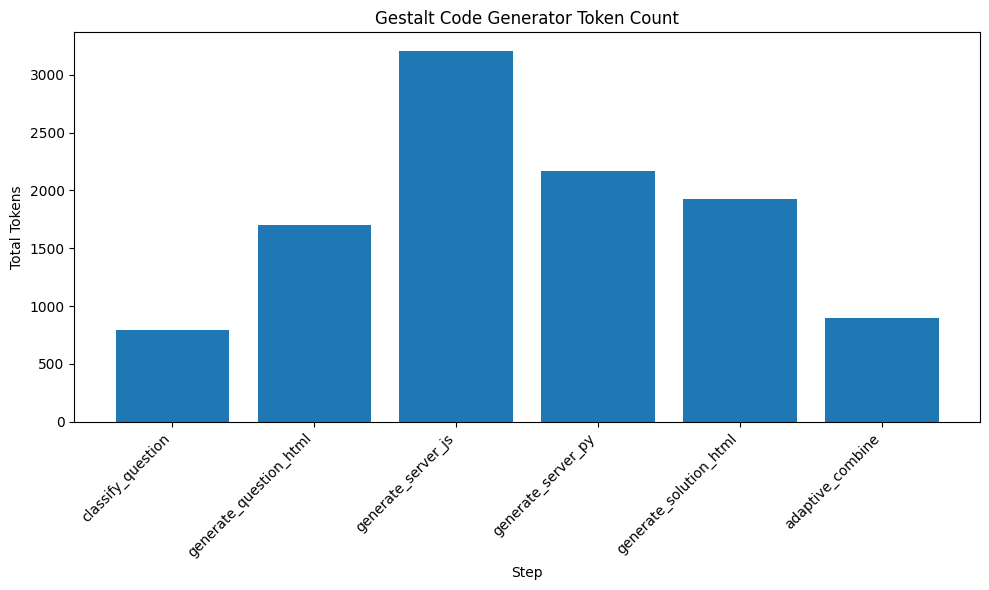

In [121]:
import matplotlib.pyplot as plt
gestalt_tokens = result["gestalt_modules"][0].token_usage
print(gestalt_tokens)
step_names = [step.step_name for step in gestalt_tokens]
total_tokens = [step.token_usage.total_tokens for step in gestalt_tokens]

plt.figure(figsize=(10, 6))
plt.bar(step_names, total_tokens)
plt.xlabel('Step')
plt.ylabel('Total Tokens')
plt.title('Gestalt Code Generator Token Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Web Search
The next step for the lecture processing is adding citation and resources to open source textbooks for example

In [122]:
from langchain_tavily import TavilySearch

tool = TavilySearch(
    max_results=5,
    topic="general",
    # include_answer=False,
    # include_raw_content=False,
    include_images=True,
    # include_image_descriptions=True,
    # search_depth="basic",
    # time_range="day",
    include_domains=["https://libretexts.org", "https://openstax.org/","https://www.youtube.com/"],
    # exclude_domains=None
)
results = tool.invoke({"query": "How to solve Tangential and Normal Directions in Polar Coordinates "})

In [125]:
print(results)

{'query': 'How to solve Tangential and Normal Directions in Polar Coordinates ', 'follow_up_questions': None, 'answer': None, 'images': ['https://i.ytimg.com/vi/KD7W4Ko-F_o/maxresdefault.jpg', 'https://i.ytimg.com/vi/0S1APz4wdpk/maxresdefault.jpg', 'https://image1.slideserve.com/3043104/slide4-l.jpg', 'https://i.ytimg.com/vi/Ad7V6MFPQcM/maxresdefault.jpg', 'https://i.ytimg.com/vi/TIjJLcmtaq8/maxresdefault.jpg'], 'results': [{'title': '9.1: Polar Coordinates - Mathematics LibreTexts', 'url': 'https://math.libretexts.org/Courses/Cosumnes_River_College/Math_373:_Trigonometry_for_Calculus/09:_Polar_Coordinates_and_Complex_Numbers/9.01:_Polar_Coordinates', 'content': 'This section introduces polar coordinates, explaining the relationship between polar and rectangular coordinates, and how to convert between them. ... = \\dfrac{x}{r} \\quad \\text {and} \\quad \\sin\\left( \\theta \\right)=\\dfrac{y}{r}\\nonumber \\]we can solve for \\(x\\) and \\(y\\), the coordinates of points on the termin

In [123]:
for r in results["results"]:
    print(r)

{'title': '9.1: Polar Coordinates - Mathematics LibreTexts', 'url': 'https://math.libretexts.org/Courses/Cosumnes_River_College/Math_373:_Trigonometry_for_Calculus/09:_Polar_Coordinates_and_Complex_Numbers/9.01:_Polar_Coordinates', 'content': 'This section introduces polar coordinates, explaining the relationship between polar and rectangular coordinates, and how to convert between them. ... = \\dfrac{x}{r} \\quad \\text {and} \\quad \\sin\\left( \\theta \\right)=\\dfrac{y}{r}\\nonumber \\]we can solve for \\(x\\) and \\(y\\), the coordinates of points on the terminal side of the angle, and obtain', 'score': 0.45769477, 'raw_content': None}
{'title': '11.3: Polar Coordinates - Mathematics LibreTexts', 'url': 'https://math.libretexts.org/Bookshelves/Calculus/Calculus_(OpenStax)/11:_Parametric_Equations_and_Polar_Coordinates/11.03:_Polar_Coordinates', 'content': '[ "article:topic", "pole", "polar axis", "Archimedean spiral", "polar coordinate system", "limacon", "cardioid", "rose", "spac

In [124]:
for r in results["images"]:
    display(Image(url=r))
    

<svg xmlns="http://www.w3.org/2000/svg" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns:inkscape="http://www.inkscape.org/namespaces/inkscape" version="1.1" width="768" height="768" viewBox="0 0 768 768">
<g transform="matrix(.75,0,0,.75,0,0)">
<image id="image_1" width="1024" height="1024" xlink:href="data:image/png;base64,
...
RK5CYII="/>
</g>
</svg>



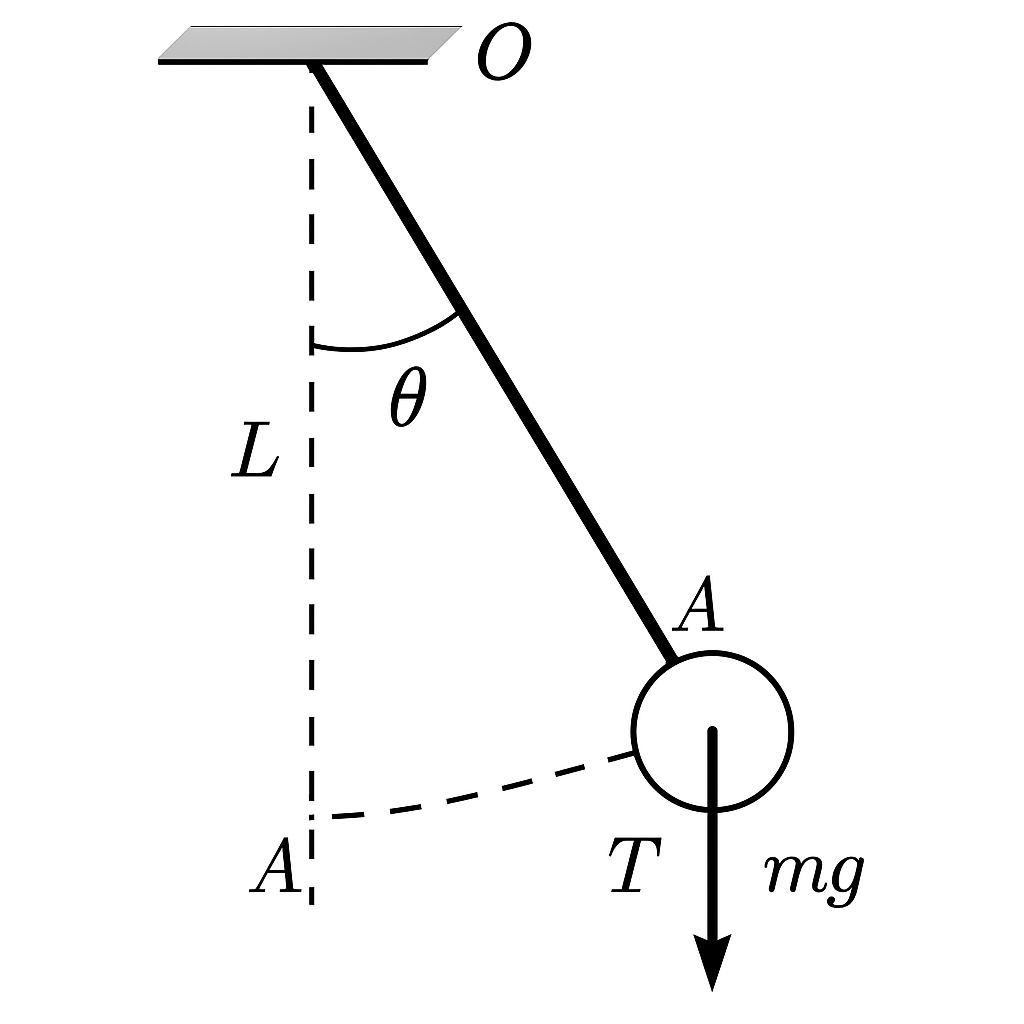

In [126]:
import fitz
path = r"C:\Users\lberm\OneDrive\Documents\Github\gestalt_app\ChatGPT Image May 1, 2025, 02_30_49 PM.png"
doc = fitz.open(path) 
page = doc[0]
pix = page.get_svg_image(matrix=fitz.Identity)
print(pix)
with open(os.path.join(basepath, "svg_output.svg"), "w",) as f:
    f.write(pix)
display(Image(filename=path))

## Next Steps

1. Integrate frontend features for generation, including the ability to download files after processing.
2. Refactor and clean up the generators for improved usability and maintainability.
3. Complete the code editor and implement routing to individual questions.
4. Add a Markdown editor for content creation, similar to the code editor.
5. Implement user authentication to enable login and personalized content access.
6. Integrate a web search mechanism into the lecture processing pipeline to enhance context and relevance.
